**In order to have a detailed understanding of the network structure, the custom loss and other details please read the README.md file on my [GitHub repository](https://github.com/damat-fla/Swirl_correction_using_Keras).**

### How to Run Inference Only

To test the model without performing any training, simply run all the cells in the **Functions Definition** and **Ensemble Model** sections, and skip all the training stages included in the **Training Phase** section.

### Notebook Structure

At the beginning of the notebook, I included the code as provided from the assignment notebook. From there, I began building my own model by defining the network architecture, the custom loss function, and all the necessary helper functions to handle model checkpointing, training resumption, model evaluation using the metric specified in the assignment, and visualization of both the loss trend and the generated images. Following this, the training cells are presented, and finally, the ensemble section concludes the notebook.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import gdown
import numpy as np
import tensorflow as tf
from skimage.draw import disk
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
from tensorflow.keras import models
import tensorflow.keras.backend as K
from tensorflow.keras.models import Model
from skimage.transform import swirl, resize
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Lambda, Add
from tensorflow.keras.layers import (Input, SeparableConv2D, Conv2D,
                                     MaxPooling2D, UpSampling2D,
                                     Concatenate, BatchNormalization,
                                     Activation, Dropout,LeakyReLU)


# FUNCTIONS DEFINITION

In [3]:
# === CONFIGURATION ===
IMG_SIZE = 128
DEFECT_RADIUS = 32  # max pixel radius of swirl defect
STRENGTH = 4 #max swirl strength
BATCH_SIZE = 32

In [4]:
def preprocess_image(sample):
    """Resize and normalize image"""
    image = tf.image.resize(sample['image'], (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image

In [5]:
def generate_swirl_defect(image_np):
    h, w = image_np.shape[:2]
    radius = int(DEFECT_RADIUS * np.random.uniform(0.5, 1.))
    strength = STRENGTH * np.random.uniform(0.5, 1.)
    center = np.random.randint(radius, h - radius, size=2)
    swirled = swirl(image_np, center=center[::-1], strength=strength, radius=radius)
    mask = np.zeros((h, w, 1), dtype=np.uint8)
    rr, cc = disk(center, radius, shape=(h, w))
    mask[rr, cc] = 1
    return swirled.astype(np.float32), mask

In [6]:
# === DATA GENERATOR ===
class SwirlDefectGenerator(tf.keras.utils.Sequence):
    def __init__(self, images, batch_size=32, shuffle=True, res="all", **kwargs):
        super().__init__(**kwargs)
        self.images = images
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(images))
        if self.shuffle:
            np.random.shuffle(self.indices)
        self.res = res


    def __len__(self):
        return len(self.images) // self.batch_size

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_clean = self.images[batch_indices]
        batch_defected = []
        batch_masks = []

        for img in batch_clean:
            swirled, mask = generate_swirl_defect(img)
            batch_defected.append(swirled)
            batch_masks.append(mask)


        if self.res == "all":
          return np.array(batch_defected), np.array(batch_masks), np.array(batch_clean)
        elif self.res=="no_mask":
            return np.array(batch_defected), np.array(batch_clean) # returns swirled and clean imges but not the mask

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [7]:
# === LOAD & SPLIT FLOWER DATA ===
def load_flower_dataset_splits(num_train=3000, num_val=300, num_test=370):
    ds = tfds.load('tf_flowers', split='train', shuffle_files=True)
    ds = ds.map(preprocess_image) #.take(num_train + num_val + num_test)
    all_images = tf.stack(list(ds))
    print(len(all_images))
    return (
        all_images[:num_train].numpy(),
        all_images[num_train:num_train + num_val].numpy(),
        all_images[num_train + num_val:num_train + num_val + num_test].numpy()
    )

In [8]:
train_imgs, val_imgs, test_imgs = load_flower_dataset_splits()

train_gen = SwirlDefectGenerator(train_imgs, batch_size=BATCH_SIZE,res="no_mask")
val_gen = SwirlDefectGenerator(val_imgs, batch_size=BATCH_SIZE, res="no_mask")
test_gen = SwirlDefectGenerator(test_imgs, batch_size=BATCH_SIZE,res="all") # return the mask only at test time

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.QSMUO6_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
3670


In [9]:
# Compute the evaluation metric over all batches in the test set.
def evaluate_model(model, test_data):
    scores = []

    for i in range(len(test_data)):

        x_batch_defected, x_batch_mask, y_batch_clean = test_data[i]

        # Compute initial MSE for defected images
        initial_mse_imgs = np.mean((x_batch_defected - y_batch_clean)**2 * x_batch_mask, axis=(1, 2, 3))
        initial_mse_batch = np.mean(initial_mse_imgs)

        # Generate images
        generated_images = model.predict(x_batch_defected, verbose=0)

        # Compute MSE for generated images
        generated_mse_imgs = np.mean((generated_images - y_batch_clean)**2 * x_batch_mask, axis=(1, 2, 3))

        # Calculate the ratio of MSEs
        mean_ratio = np.mean(generated_mse_imgs / initial_mse_batch)
        scores.append(mean_ratio)
        print(f"Batch {i+1}/{len(test_gen)} —------ Average score (Generated / Initial): {mean_ratio:.4f}")

    scores = np.array(scores)
    overall_mean = np.mean(scores)
    overall_std = np.std(scores)

    print(f"\nFinal average score over all batches: {overall_mean:.4f}")
    print(f"Standard deviation across all batches: {overall_std:.4f}")
    return overall_mean, overall_std


In [ ]:
# Define a conv block as conv - batch_norm - activation twice
# I chose SeparableConv2D because it achieves similar results to standard Conv2D
# while using fewer parameters, allowing to use more filters without increasing model size.

def conv_block(x, filters, dilation_rate=1, dropout_rate=0.0):
    x = SeparableConv2D(filters, (3,3), padding='same',
                        dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(negative_slope=0.1)(x)

    x = SeparableConv2D(filters, (3,3), padding='same',
                        dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = LeakyReLU(negative_slope=0.1)(x)

    if dropout_rate > 0.0:
        x = Dropout(dropout_rate)(x)
    return x

# Create a U-Net like architecture
def build_model(input_shape=(128, 128, 3), base_filters=128, output_channels=3, dropout_rate=0.1):
    inputs = Input(shape=input_shape)

    # Encoder (stop at 32x32)
    c1 = conv_block(inputs, base_filters)          # 128x128
    p1 = MaxPooling2D(pool_size=(2, 2))(c1)            # 64x64

    c2 = conv_block(p1, base_filters * 2)          # 64x64
    p2 = MaxPooling2D(pool_size=(2, 2))(c2)            # 32x32

    # Bottleneck (32x32) - no further downsampling
    bn = conv_block(p2, base_filters * 4, dilation_rate=2, dropout_rate=dropout_rate)

    # Decoder
    u2 = UpSampling2D()(bn)
    u2 = Concatenate()([u2, c2])
    c3 = conv_block(u2, base_filters * 2, dropout_rate=dropout_rate)

    u1 = UpSampling2D()(c3)
    u1 = Concatenate()([u1, c1])
    c4 = conv_block(u1, base_filters, dropout_rate=dropout_rate)

    outputs = Conv2D(output_channels, (1, 1), activation='sigmoid')(c4)

    return Model(inputs, outputs)


In [ ]:
def patchwise_topk_loss(k=5, patch_size=32):
    def loss(y_true, y_pred):
        # patchify images in non-overlapping patches
        patches_true = tf.image.extract_patches(
            images=y_true,
            sizes=[1, patch_size, patch_size, 1],
            strides=[1, patch_size, patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID'
        )
        patches_pred = tf.image.extract_patches(
            images=y_pred,
            sizes=[1, patch_size, patch_size, 1],
            strides=[1, patch_size, patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID'
        )
        # compute mse patch by patch
        error = tf.square(patches_true - patches_pred)
        patch_loss = tf.reduce_mean(error, axis=-1)  # [batch, n_h, n_w]

        # Consder only the k worst patches and take the mean
        batch_size = tf.shape(patch_loss)[0]
        top_k_loss = tf.map_fn(
            lambda x: tf.math.top_k(tf.reshape(x, [-1]), k=k).values,
            patch_loss
        )
        return tf.reduce_mean(top_k_loss)

    return loss


def pixelwise_topk_loss(k=0.05):  # k between 0 and 1 representing the amount of pixel to consider
    def loss(y_true, y_pred):

        # compute MSE over all pixels of the images
        error = tf.square(y_true - y_pred)  # shape: [batch, H, W, C]
        error = tf.reduce_mean(error, axis=-1)

        # Sort pixels by MSE and choose the k percentage worst
        def topk_mean(err_map):
            flat = tf.reshape(err_map, [-1])
            n_pixels = tf.shape(flat)[0]

            if isinstance(k, float):
                top_k = tf.cast(tf.cast(n_pixels, tf.float32) * k, tf.int32)
            else:
                top_k = tf.minimum(k, n_pixels)

            topk_vals = tf.math.top_k(flat, k=top_k, sorted=False).values
            return tf.reduce_mean(topk_vals)

        # Apply the topk_mean function to each image in the batch
        topk_per_batch = tf.map_fn(topk_mean, error)
        return tf.reduce_mean(topk_per_batch)

    return loss

# compute sobel edges along the two main directions of the image
def sobel_edges(x):
    gx = tf.image.sobel_edges(x)[..., 0]
    gy = tf.image.sobel_edges(x)[..., 1]
    return tf.sqrt(gx**2 + gy**2 + 1e-6)

def patchwise_topk_gradient_loss(k=5, patch_size=16):
    def loss(y_true, y_pred):
        # extract edges of both the original and the predicted
        grad_true = sobel_edges(y_true)
        grad_pred = sobel_edges(y_pred)

        # patchify iamges
        patches_true = tf.image.extract_patches(
            images=grad_true,
            sizes=[1, patch_size, patch_size, 1],
            strides=[1, patch_size, patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID'
        )
        patches_pred = tf.image.extract_patches(
            images=grad_pred,
            sizes=[1, patch_size, patch_size, 1],
            strides=[1, patch_size, patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID'
        )

        # compute MSE patch by patch
        error = tf.square(patches_true - patches_pred)
        patch_loss = tf.reduce_mean(error, axis=-1)

        # consider only the worst patches
        top_k_loss = tf.map_fn(
            lambda x: tf.math.top_k(tf.reshape(x, [-1]), k=k).values,
            patch_loss
        )
        return tf.reduce_mean(top_k_loss)
    return loss

# Define a combined loss that compute a weighted sum of the 3 previous losses
def combo_loss(k=5, patch_size=16, alpha=1.0, beta=1.0, gamma=1.0):
    patch_loss_fn = patchwise_topk_loss(k, patch_size)
    grad_loss_fn = patchwise_topk_gradient_loss(k, patch_size)
    pixelwise_loss_fn = pixelwise_topk_loss(0.05)

    # weight each loss
    def loss(y_true, y_pred):
        return alpha * patch_loss_fn(y_true, y_pred) + beta * grad_loss_fn(y_true, y_pred) + gamma * pixelwise_loss_fn(y_true, y_pred)

    return loss


In [12]:
# Callback to save the model
def get_checkpoint_callback(save_to):
  checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
      filepath=save_to,
      save_best_only=False,         # save at the end of each epoch
      monitor='loss',          # metric to monitor during training
      mode='min',                  # seek for the minimum of the loss
      save_weights_only=True,     # save weights only
      verbose=1                    # print out every time it saves a model
  )

  return checkpoint_cb


In [ ]:
# a function that takes all the needed parameters to load a model from a checkpoint, compile the model, fit it and save the results
def restart_training_weights(weights_path, save_to, train_data, val_data, lr, k, patch_size, alpha, beta, gamma, total_epochs, initial_epoch):

    optimizer = Adam(learning_rate=lr)
    model = build_model()
    model.compile(optimizer=optimizer,
                  loss=combo_loss(k=k, patch_size=patch_size, alpha=alpha, beta=beta, gamma=gamma)
                  )

    # Load weights if the path contains them
    if os.path.exists(weights_path):
        model.load_weights(weights_path)
        print(f"Weights loaded from: {weights_path}")
    else:
        print("Weights not found, starting training from the beginning")

    # fit the model just loaded
    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=total_epochs,
        initial_epoch=initial_epoch,
        callbacks=[get_checkpoint_callback(save_to)]
    )

    return model, history

In [ ]:
def visualize_results(model, test_data, num_examples=3):
    # Extract a random batch
    idx = np.random.randint(0, len(test_data))
    x_batch_defected, x_batch_mask, y_batch_clean = test_data[idx]

    # Make prediction with that batch
    generated_images = model.predict(x_batch_defected, verbose=0)

    batch_size = y_batch_clean.shape[0]
    mask_broadcast = np.repeat(x_batch_mask, 3, axis=-1)

    # Select random images from the batch
    rng = np.random.default_rng()
    indices = rng.choice(batch_size, size=num_examples, replace=False)

    plt.figure(figsize=(num_examples * 4, 4 * 3))

    for i, idx in enumerate(indices):

        # Columns: 0=Mask, 1=Original, 2=Defected, 3=Generated
        plt.subplot(num_examples, 4, i * 4 + 1)
        plt.imshow(x_batch_mask[idx, ..., 0], cmap='gray')
        plt.title("Mask")
        plt.axis("off")

        plt.subplot(num_examples, 4, i * 4 + 2)
        plt.imshow(y_batch_clean[idx])
        plt.title("Original")
        plt.axis("off")

        plt.subplot(num_examples, 4, i * 4 + 3)
        plt.imshow(x_batch_defected[idx])
        plt.title("Defected")
        plt.axis("off")

        plt.subplot(num_examples, 4, i * 4 + 4)
        plt.imshow(generated_images[idx])
        plt.title("Generated")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
def visualize_history(history, start_epoch=0, end_epoch=None, visualize_validation=True):
    epochs = range(start_epoch , end_epoch + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history.history['loss'], label='Training Loss')
    if 'val_loss' in history.history and visualize_validation:
        plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss History')
    plt.legend()
    plt.grid(True, linestyle='--')
    plt.tight_layout()
    plt.show()


# TRAINING PHASE

### Stage 1 (epochs 0–40)  
**Learning rate**: 0.0015  
**Loss weights**: α = 1, β = 0, γ = 0

In this initial phase, training focuses exclusively on the **Patchwise Loss**, completely ignoring edge and pixel-level errors. The goal is to guide the model toward learning a coarse correction of the most distorted regions, identified by selecting the patches with the highest error. At this stage, it's more beneficial to help the network handle the overall structure of the image rather than fine-tune the details.


In [ ]:
model = build_model()

optimizer = Adam(learning_rate=0.0015)

model.compile(optimizer=optimizer, loss=combo_loss(k=16, patch_size=16, alpha=1, beta=0, gamma=0))

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_10 │ (None, 128, 128,  │        539 │ input_layer_1[0]… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_10      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_11 │ (None, 128, 128,  │     17,664 │ leaky_re_lu_10[0… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_11      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 64, 64,    │          0 │ leaky_re_lu_11[0… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_12 │ (None, 64, 64,    │     34,176 │ max_pooling2d_2[… │
│ (SeparableConv2D)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ separable_conv2d… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_12      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_13 │ (None, 64, 64,    │     68,096 │ leaky_re_lu_12[0… │
│ (SeparableConv2D)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ separable_conv2d… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_13      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32,    │          0 │ leaky_re_lu_13[0… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_14 │ (None, 32, 32,    │    133,888 │ max_pooling2d_3[… │
│ (SeparableConv2D)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      2,048 │ separable_conv2d

 Total params: 874,526 (3.34 MB)

 Trainable params: 869,406 (3.32 MB)

 Non-trainable params: 5,120 (20.00 KB)

In [ ]:
save_to = "/content/drive/MyDrive/Colab Notebooks/swirl_correction/example/model.weights.h5"
checkpoint = get_checkpoint_callback(save_to)

history = model.fit(train_gen, validation_data=val_gen, epochs=40, callbacks=[checkpoint])

Epoch 1/40
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - loss: 0.0388
Epoch 1: loss improved from inf to 0.01781, saving model to /content/drive/MyDrive/Colab Notebooks/swirl_correction/partial_compression_new_trial/model.weights.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 82s 302ms/step - loss: 0.0385 - val_loss: 0.1378
Epoch 2/40
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - loss: 0.0079
Epoch 2: loss improved from 0.01781 to 0.00750, saving model to /content/drive/MyDrive/Colab Notebooks/swirl_correction/partial_compression_new_trial/model.weights.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 26s 275ms/step - loss: 0.0079 - val_loss: 0.1350
Epoch 3/40
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - loss: 0.0067
Epoch 3: loss improved from 0.00750 to 0.00665, saving model to /content/drive/MyDrive/Colab Notebooks/swirl_correction/partial_compression_new_trial/model.weights.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 26s 278ms/step - loss: 0.0067 - val_loss: 0.1285
Epoch 4/40
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - loss: 0.0061
Epoch 4

In [ ]:
mean, std = evaluate_model(model, test_gen)

Batch 1/11 —------ Average score (Generated / Initial): 0.4414
Batch 2/11 —------ Average score (Generated / Initial): 0.4523
Batch 3/11 —------ Average score (Generated / Initial): 0.4272
Batch 4/11 —------ Average score (Generated / Initial): 0.4668
Batch 5/11 —------ Average score (Generated / Initial): 0.4355
Batch 6/11 —------ Average score (Generated / Initial): 0.4547
Batch 7/11 —------ Average score (Generated / Initial): 0.4030
Batch 8/11 —------ Average score (Generated / Initial): 0.4382
Batch 9/11 —------ Average score (Generated / Initial): 0.4762
Batch 10/11 —------ Average score (Generated / Initial): 0.4339
Batch 11/11 —------ Average score (Generated / Initial): 0.4531

Final average score over all batches: 0.4439
Standard deviation across all batches: 0.0191


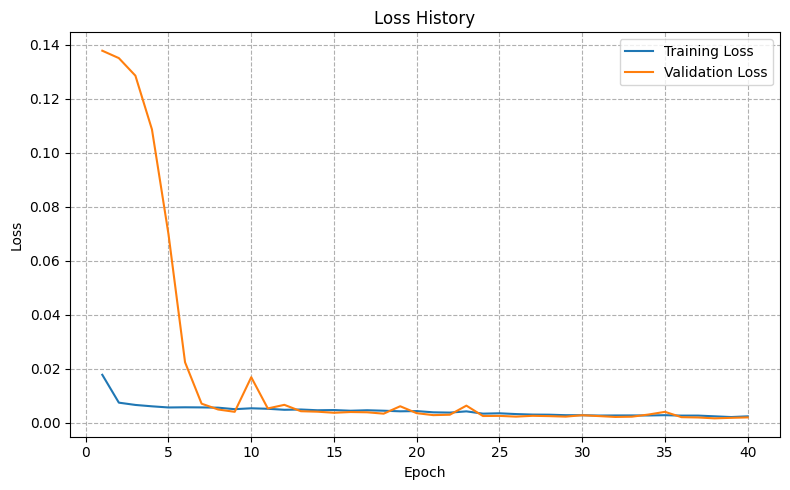

In [ ]:
# Visualize hsitory progression
visualize_history(history, start_epoch=1, end_epoch=40, visualize_validation=True)

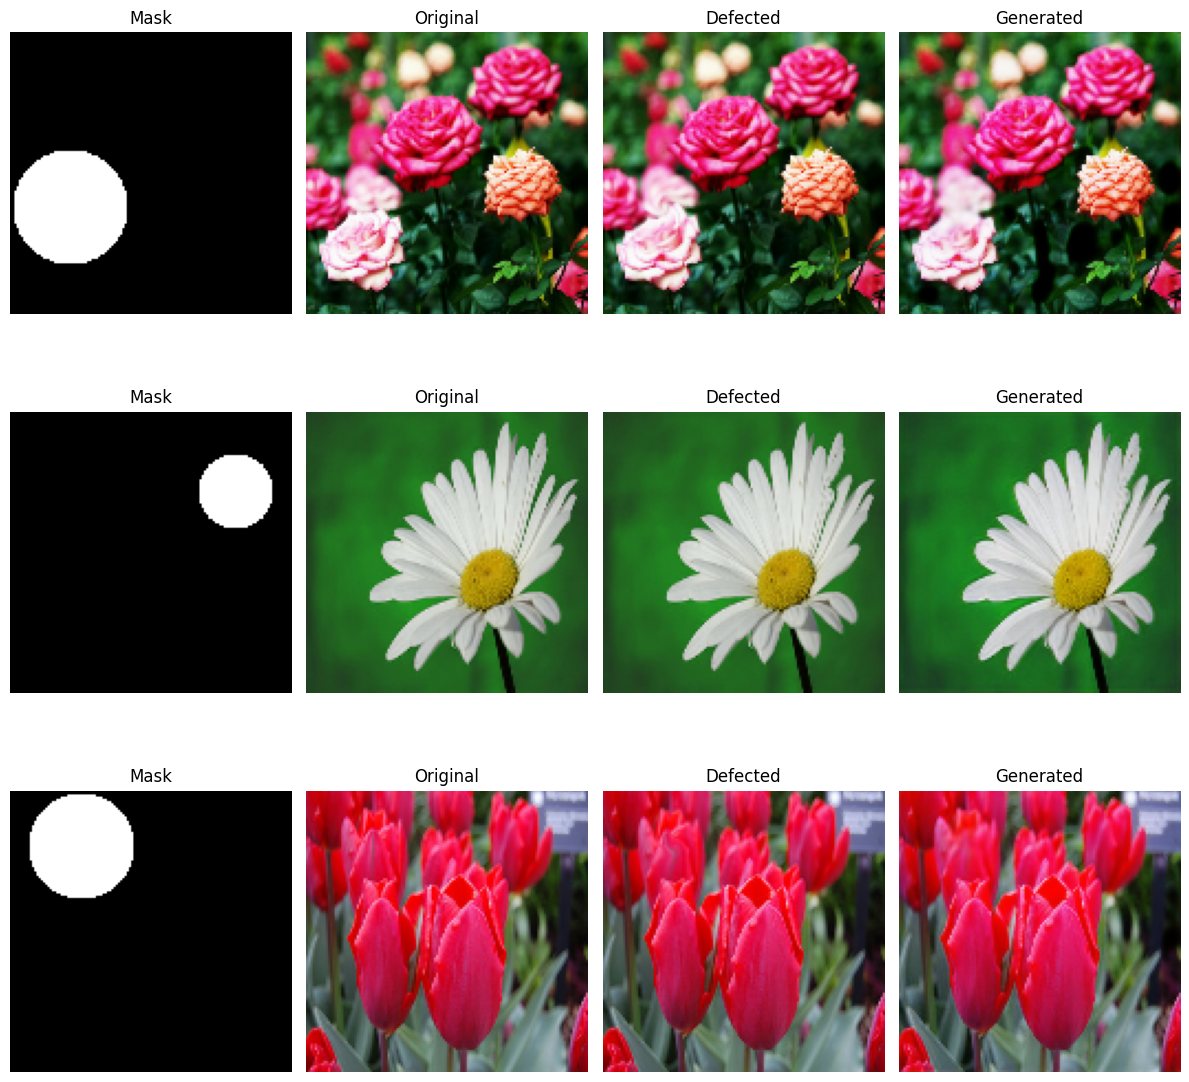

In [ ]:
visualize_results(model, test_gen, num_examples=3)

### Stage 2 (epochs 40–90)  
**Learning rate**: 0.0015  
**Loss weights**: α = 0.5, β = 0.5, γ = 0

In the previous stage, the model learned to reconstruct the overall structure of the image. However, it still struggles in the region affected by the swirl. In this phase, the **Edge Loss** is introduced, with the goal of encouraging the model to accurately reconstruct edges, especially within the distorted area.


In [ ]:
load_from = "/content/drive/MyDrive/Colab Notebooks/swirl_correction/example/model.weights.h5"
save_to = "/content/drive/MyDrive/Colab Notebooks/swirl_correction/example/model40-90.weights.h5"
model, history = restart_training_weights(
    weights_path=load_from,
    save_to=save_to,
    train_data=train_gen,
    val_data=val_gen,
    lr=0.0015,
    patch_size=16,
    k=8,
    alpha=0.5,
    beta=0.5,
    gamma=0,
    total_epochs=90,
    initial_epoch=40

)

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 106 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Weights loaded from: /content/drive/MyDrive/Colab Notebooks/swirl_correction/partial_compression_new_trial/model.weights.h5
Epoch 41/90
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - loss: 0.0291
Epoch 41: loss improved from inf to 0.02696, saving model to /content/drive/MyDrive/Colab Notebooks/swirl_correction/partial_compression_new_trial/model40-90.weights.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 46s 300ms/step - loss: 0.0291 - val_loss: 0.0249
Epoch 42/90
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - loss: 0.0235
Epoch 42: loss improved from 0.02696 to 0.02289, saving model to /content/drive/MyDrive/Colab Notebooks/swirl_correction/partial_compression_new_trial/model40-90.weights.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 26s 280ms/step - loss: 0.0235 - val_loss: 0.0236
Epoch 43/90
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - loss: 0.0242
Epoch 43: loss did not improve from 0.02289
93/93 ━━━━━━━━━━━━━━━━━━━━ 25s 270ms/step - loss: 0.0242 - val_loss: 0.0211
Epoch 44/90
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - los

In [ ]:
mean, std = evaluate_model(model, test_gen)

Batch 1/11 —------ Average score (Generated / Initial): 0.2750
Batch 2/11 —------ Average score (Generated / Initial): 0.2459
Batch 3/11 —------ Average score (Generated / Initial): 0.2070
Batch 4/11 —------ Average score (Generated / Initial): 0.2209
Batch 5/11 —------ Average score (Generated / Initial): 0.2447
Batch 6/11 —------ Average score (Generated / Initial): 0.2597
Batch 7/11 —------ Average score (Generated / Initial): 0.2095
Batch 8/11 —------ Average score (Generated / Initial): 0.2700
Batch 9/11 —------ Average score (Generated / Initial): 0.2066
Batch 10/11 —------ Average score (Generated / Initial): 0.2232
Batch 11/11 —------ Average score (Generated / Initial): 0.2475

Final average score over all batches: 0.2373
Standard deviation across all batches: 0.0240


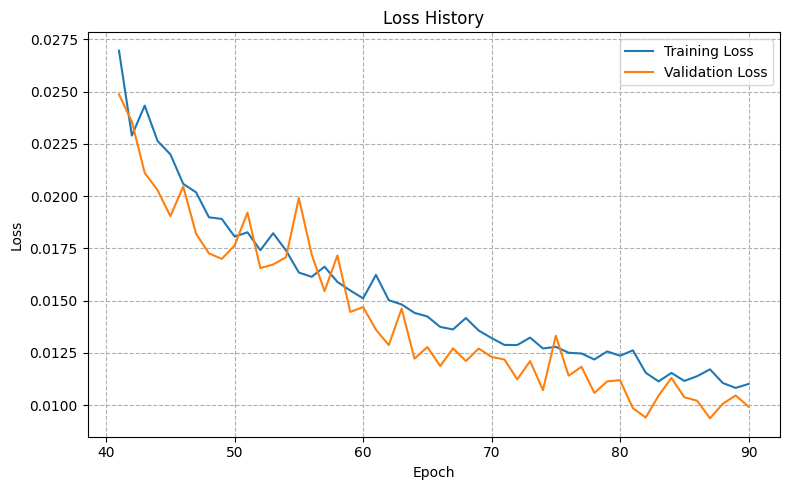

In [ ]:
# Visualize hsitory progression
visualize_history(history,start_epoch=41, end_epoch=90, visualize_validation=True)

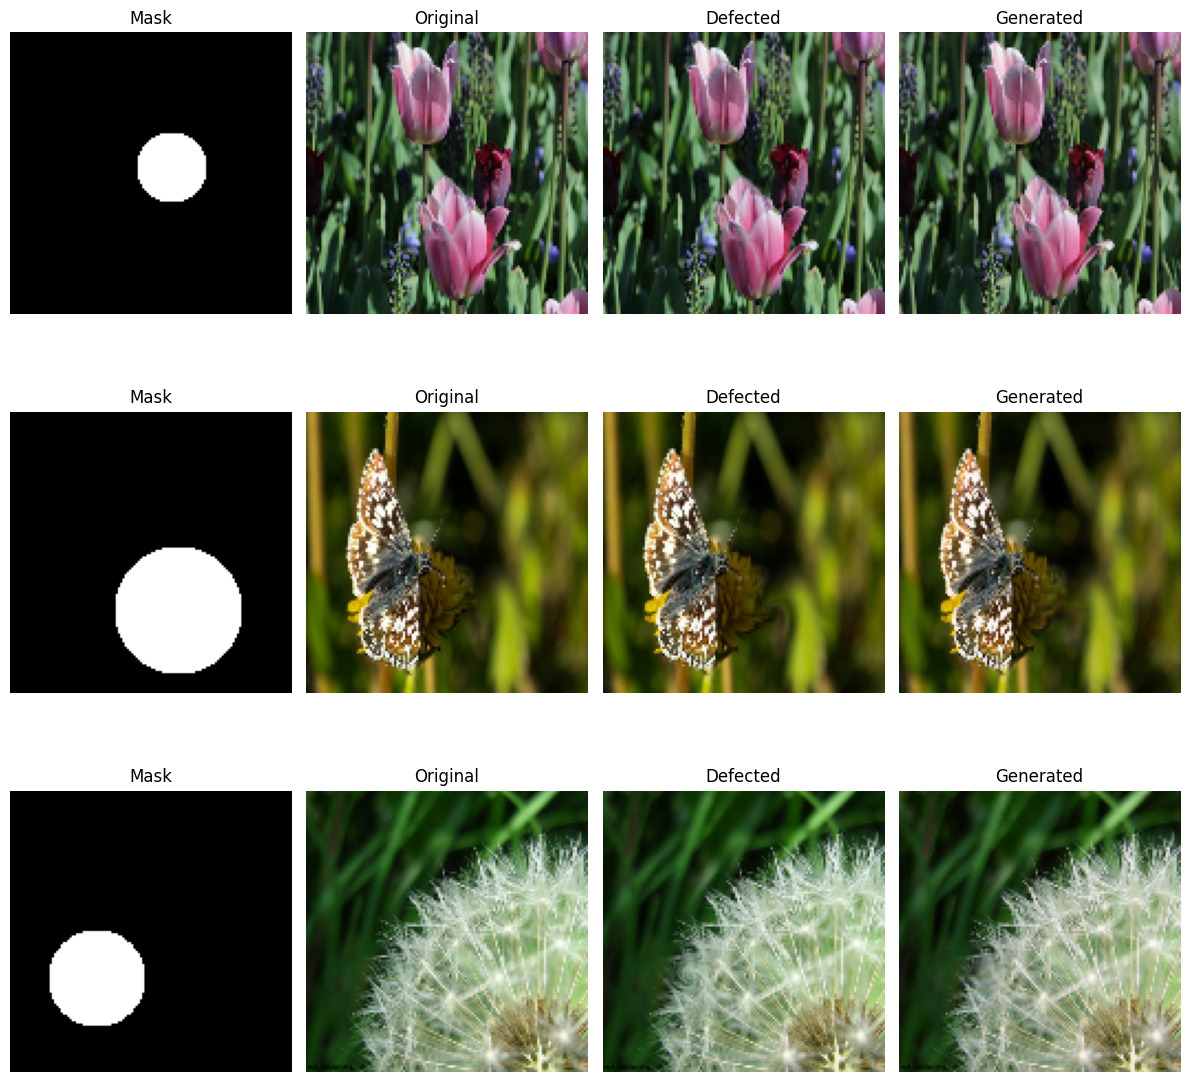

In [ ]:
visualize_results(model, test_gen, num_examples=3)

### Stage 3 (epochs 90–120)  
**Learning rate**: 0.001  
**Loss weights**: α = 0.3, β = 0.4, γ = 0.3

To further enhance edge sharpness and refine image details, this stage introduces the **Pixelwise Loss**. This allows the model to focus more precisely on the pixels with the highest error, enabling a more accurate correction of problematic areas and a more refined overall reconstruction.


In [ ]:
load_from = "/content/drive/MyDrive/Colab Notebooks/swirl_correction/example/model40-90.weights.h5"
save_to = "/content/drive/MyDrive/Colab Notebooks/swirl_correction/example/model90-120.weights.h5"
model, history = restart_training_weights(
    weights_path=load_from,
    save_to=save_to,
    train_data=train_gen,
    val_data=val_gen,
    lr=0.001,
    patch_size=16,
    k=8,
    alpha=0.3,
    beta=0.4,
    gamma=0.3,
    total_epochs=120,
    initial_epoch=90
)


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 106 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Weights loaded from: /content/drive/MyDrive/Colab Notebooks/swirl_correction/partial_compression_new_trial/model40-90.weights.h5
Epoch 91/120
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - loss: 0.0103
Epoch 91: saving model to /content/drive/MyDrive/Colab Notebooks/swirl_correction/partial_compression_new_trial/model90-120.weights.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 45s 299ms/step - loss: 0.0103 - val_loss: 0.0086
Epoch 92/120
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - loss: 0.0099
Epoch 92: saving model to /content/drive/MyDrive/Colab Notebooks/swirl_correction/partial_compression_new_trial/model90-120.weights.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 26s 274ms/step - loss: 0.0099 - val_loss: 0.0075
Epoch 93/120
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - loss: 0.0102
Epoch 93: saving model to /content/drive/MyDrive/Colab Notebooks/swirl_correction/partial_compression_new_trial/model90-120.weights.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 26s 277ms/step - loss: 0.0102 - val_loss: 0.0082
Epoch 94/120
93/93 ━━━━━━━━━━━━

In [ ]:
mean, std = evaluate_model(model, test_gen)

Batch 1/11 —------ Average score (Generated / Initial): 0.2209
Batch 2/11 —------ Average score (Generated / Initial): 0.2165
Batch 3/11 —------ Average score (Generated / Initial): 0.1737
Batch 4/11 —------ Average score (Generated / Initial): 0.1826
Batch 5/11 —------ Average score (Generated / Initial): 0.1811
Batch 6/11 —------ Average score (Generated / Initial): 0.1925
Batch 7/11 —------ Average score (Generated / Initial): 0.2071
Batch 8/11 —------ Average score (Generated / Initial): 0.1924
Batch 9/11 —------ Average score (Generated / Initial): 0.2168
Batch 10/11 —------ Average score (Generated / Initial): 0.1748
Batch 11/11 —------ Average score (Generated / Initial): 0.2317

Final average score over all batches: 0.1991
Standard deviation across all batches: 0.0194


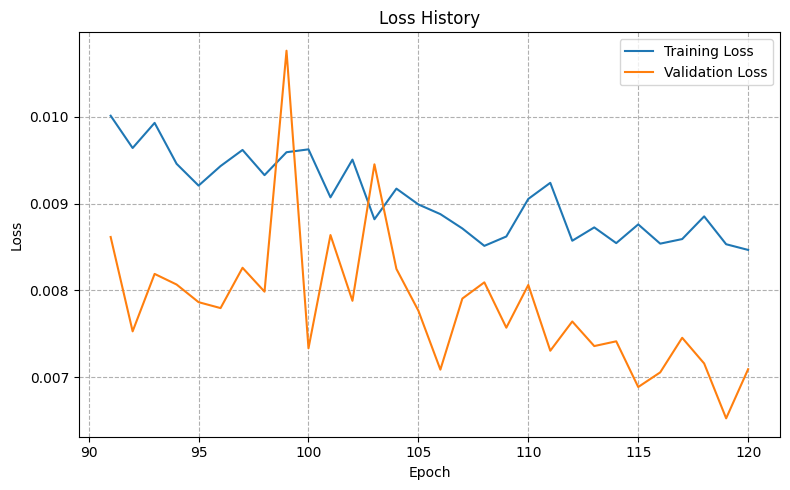

In [ ]:
# Visualize hsitory progression
visualize_history(history, start_epoch=91, end_epoch=120, visualize_validation=True)

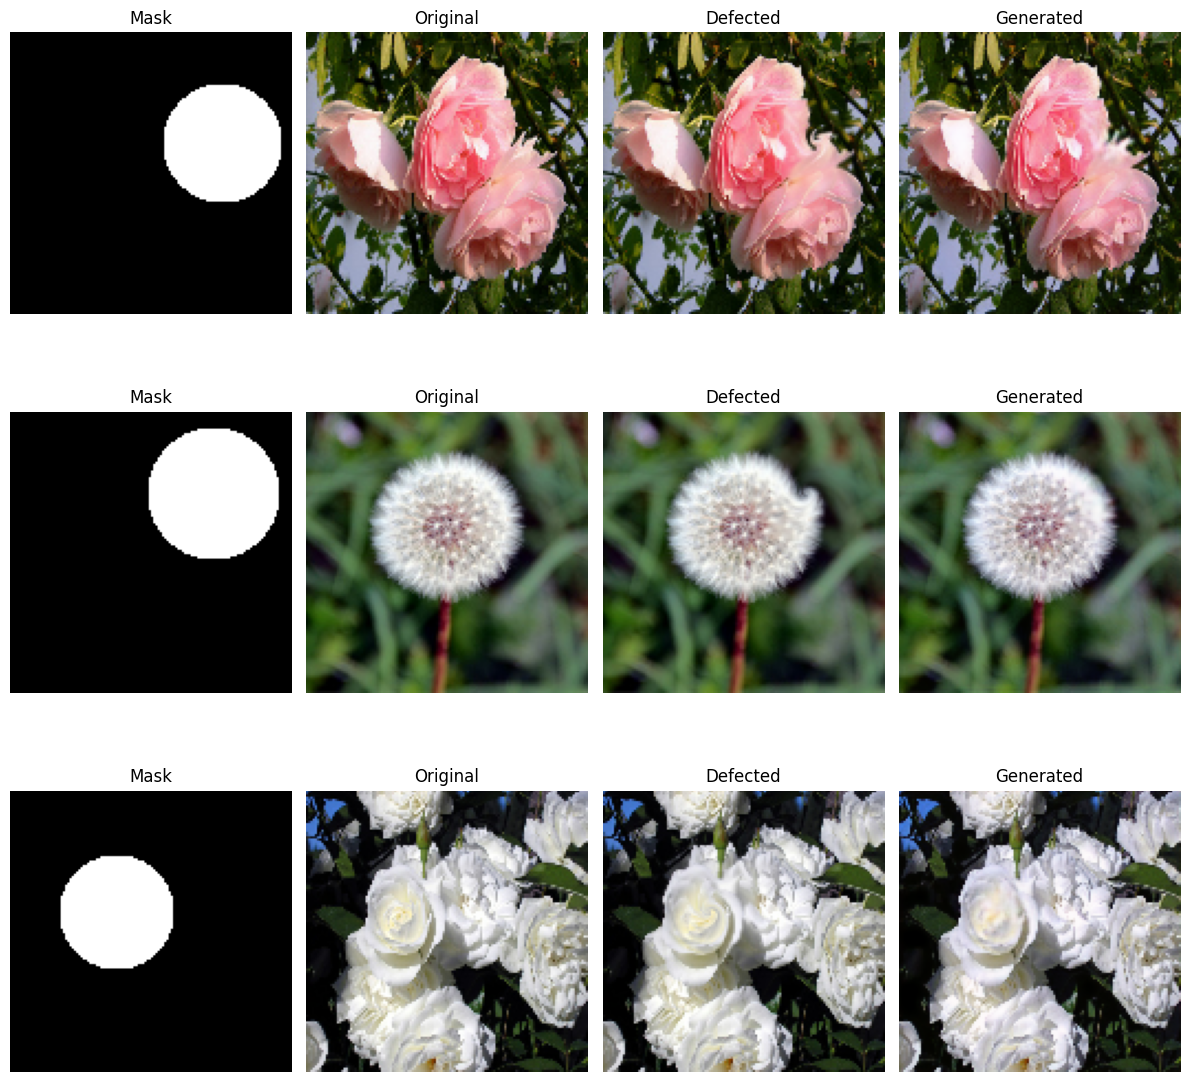

In [ ]:
visualize_results(model, test_gen, num_examples=3)

### Stage 4 (epochs 120–150)  
**Learning rate**: 0.0005  
**Loss weights**: α = 0.15, β = 0.5, γ = 0.35

In this stage, the learning rate is reduced to help stabilize training. Since the model has already learned to reconstruct the coarser details of the image, we decrease the weight of the Patchwise Loss in favor of the Edge and Pixelwise Losses, allowing the model to focus more on finer details and edge precision.


In [ ]:
load_from = "/content/drive/MyDrive/Colab Notebooks/swirl_correction/example/model90-120.weights.h5"
save_to = "/content/drive/MyDrive/Colab Notebooks/swirl_correction/example/model_120-150.weights.h5"
model, history = restart_training_weights(
    weights_path=load_from,
    save_to=save_to,
    train_data=train_gen,
    val_data=val_gen,
    lr=0.0005,
    patch_size=16,
    k=8,
    alpha=0.15,
    beta=0.5,
    gamma=0.35,
    total_epochs=150,
    initial_epoch=120

)

Weights loaded from: /content/drive/MyDrive/Colab Notebooks/swirl_correction/partial_compression_new_trial/model90-120.weights.h5
Epoch 121/150
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - loss: 0.0100
Epoch 121: saving model to /content/drive/MyDrive/Colab Notebooks/swirl_correction/partial_compression_new_trial/model_120-150.weights.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 46s 298ms/step - loss: 0.0099 - val_loss: 0.0090
Epoch 122/150
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - loss: 0.0094
Epoch 122: saving model to /content/drive/MyDrive/Colab Notebooks/swirl_correction/partial_compression_new_trial/model_120-150.weights.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 26s 275ms/step - loss: 0.0094 - val_loss: 0.0085
Epoch 123/150
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - loss: 0.0095
Epoch 123: saving model to /content/drive/MyDrive/Colab Notebooks/swirl_correction/partial_compression_new_trial/model_120-150.weights.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 26s 276ms/step - loss: 0.0095 - val_loss: 0.0076
Epoch 124/150
93/9

In [ ]:
mean, std = evaluate_model(model, test_gen)

Batch 1/11 —------ Average score (Generated / Initial): 0.1825
Batch 2/11 —------ Average score (Generated / Initial): 0.1873
Batch 3/11 —------ Average score (Generated / Initial): 0.1658
Batch 4/11 —------ Average score (Generated / Initial): 0.1556
Batch 5/11 —------ Average score (Generated / Initial): 0.1792
Batch 6/11 —------ Average score (Generated / Initial): 0.1858
Batch 7/11 —------ Average score (Generated / Initial): 0.1698
Batch 8/11 —------ Average score (Generated / Initial): 0.1796
Batch 9/11 —------ Average score (Generated / Initial): 0.1595
Batch 10/11 —------ Average score (Generated / Initial): 0.1722
Batch 11/11 —------ Average score (Generated / Initial): 0.2108

Final average score over all batches: 0.1771
Standard deviation across all batches: 0.0146


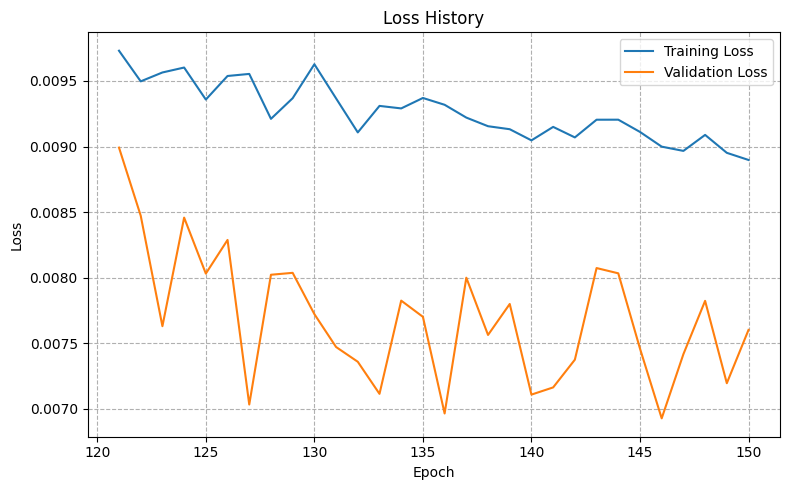

In [ ]:
# Visualize hsitory progression
visualize_history(history, start_epoch=121, end_epoch=150, visualize_validation=True)

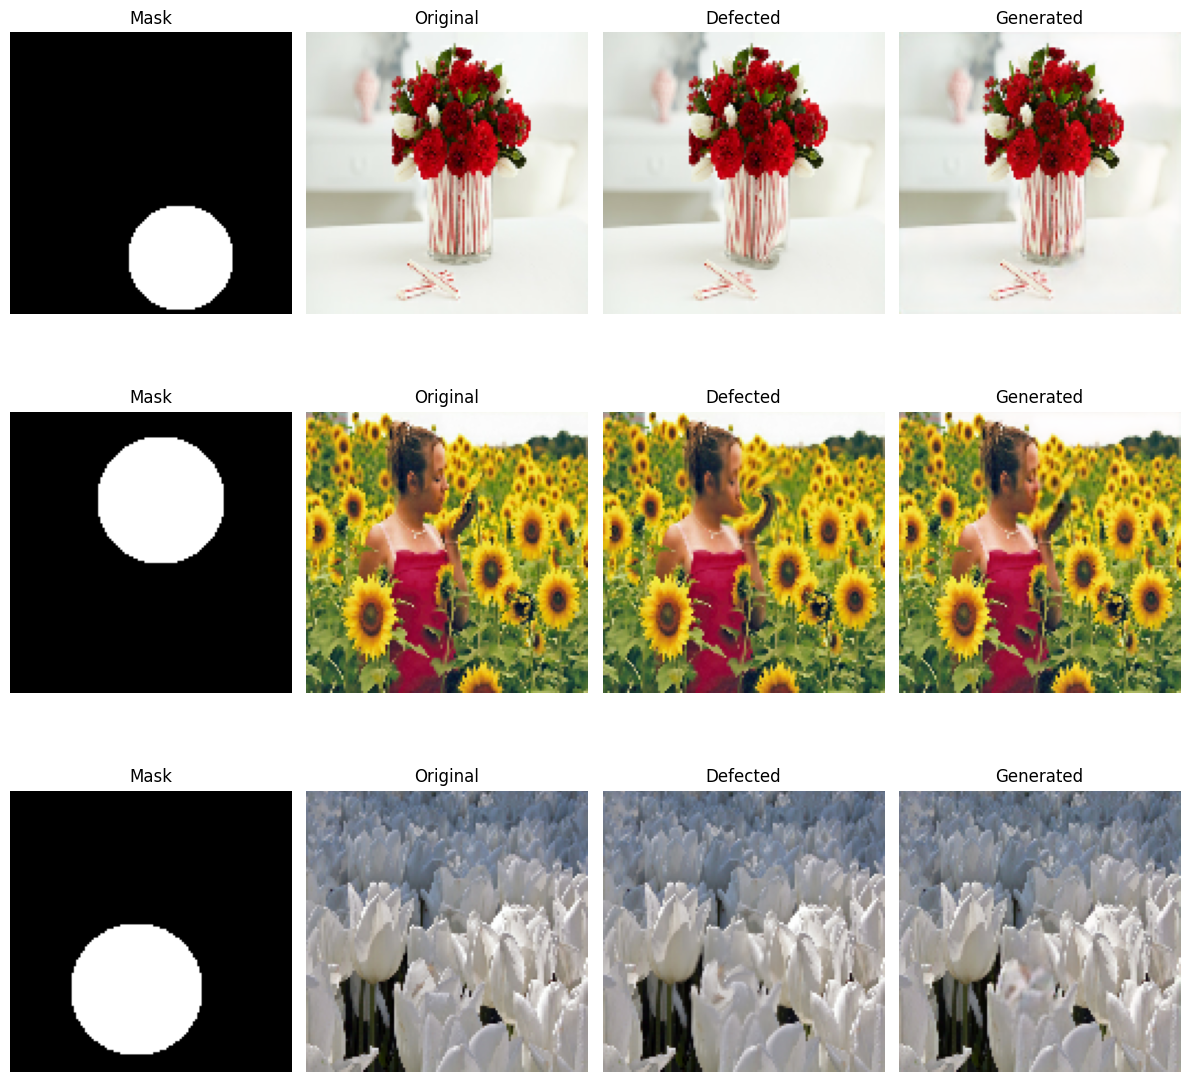

In [ ]:
visualize_results(model, test_gen, num_examples=3)

### Stage 5 (epochs 150–170)  
**Learning rate**: 0.0003  
**Loss weights**: α = 0.15, β = 0.5, γ = 0.35

In this final stage, the learning rate is further reduced and the model is trained for a few additional epochs. The goal is to fine-tune the weights and achieve a more refined and stable reconstruction.


In [ ]:
load_from = "/content/drive/MyDrive/Colab Notebooks/swirl_correction/example/model_120-150.weights.h5"
save_to = "/content/drive/MyDrive/Colab Notebooks/swirl_correction/example/model150-170.weights.h5"
model, history = restart_training_weights(
    weights_path=load_from,
    save_to=save_to,
    train_data=train_gen,
    val_data=val_gen,
    lr=0.0003,
    patch_size=16,
    k=8,
    alpha=0.15,
    beta=0.5,
    gamma=0.35,
    total_epochs=170,
    initial_epoch=150
)

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 106 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Weights loaded from: /content/drive/MyDrive/Colab Notebooks/swirl_correction/partial_compression_new_trial/model_120-150.weights.h5
Epoch 151/170
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - loss: 0.0086
Epoch 151: saving model to /content/drive/MyDrive/Colab Notebooks/swirl_correction/partial_compression_new_trial/model150-170.weights.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 44s 291ms/step - loss: 0.0086 - val_loss: 0.0069
Epoch 152/170
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - loss: 0.0090
Epoch 152: saving model to /content/drive/MyDrive/Colab Notebooks/swirl_correction/partial_compression_new_trial/model150-170.weights.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 25s 273ms/step - loss: 0.0090 - val_loss: 0.0075
Epoch 153/170
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - loss: 0.0092
Epoch 153: saving model to /content/drive/MyDrive/Colab Notebooks/swirl_correction/partial_compression_new_trial/model150-170.weights.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 26s 280ms/step - loss: 0.0092 - val_loss: 0.0078
Epoch 154/170
93/93

In [ ]:
mean, std = evaluate_model(model, test_gen)

Batch 1/11 —------ Average score (Generated / Initial): 0.1594
Batch 2/11 —------ Average score (Generated / Initial): 0.1784
Batch 3/11 —------ Average score (Generated / Initial): 0.1280
Batch 4/11 —------ Average score (Generated / Initial): 0.1364
Batch 5/11 —------ Average score (Generated / Initial): 0.1705
Batch 6/11 —------ Average score (Generated / Initial): 0.1445
Batch 7/11 —------ Average score (Generated / Initial): 0.1397
Batch 8/11 —------ Average score (Generated / Initial): 0.1763
Batch 9/11 —------ Average score (Generated / Initial): 0.1497
Batch 10/11 —------ Average score (Generated / Initial): 0.1638
Batch 11/11 —------ Average score (Generated / Initial): 0.1612

Final average score over all batches: 0.1553
Standard deviation across all batches: 0.0160


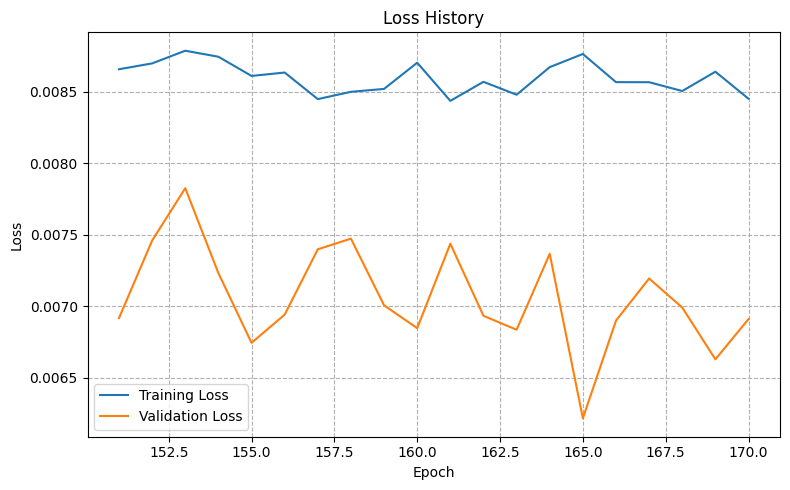

In [ ]:
# Visualize hsitory progression
visualize_history(history, start_epoch=151, end_epoch=170, visualize_validation=True)

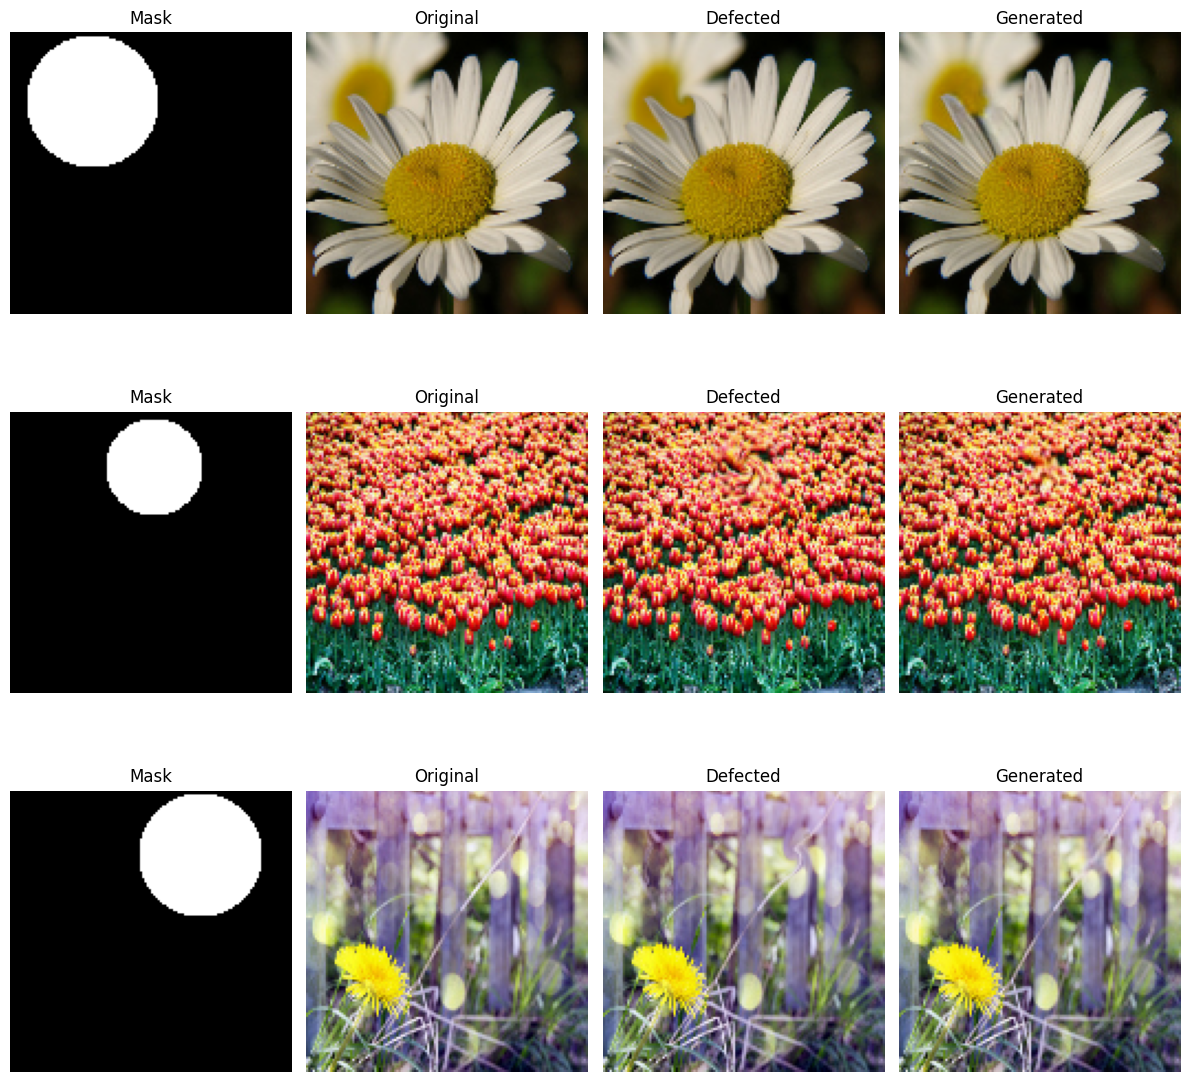

In [ ]:
visualize_results(model, test_gen, num_examples=3)

# ENSEMBLE MODEL

Now that the training is complete, we proceed to create the ensemble model by combining the four trained networks, as described on my [GitHub repository](https://github.com/damat-fla/Swirl_correction_using_Keras). Before creating the ensemble I have to report also the architecture using the ReLu activation function because I saved only the weights during training and not the whole model


In [13]:
#####   U-NET with ReLU activation function    #####

def conv_block_relu(x, filters, dilation_rate=1, dropout_rate=0.0):
    x = SeparableConv2D(filters, (3,3), padding='same',
                        dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = SeparableConv2D(filters, (3,3), padding='same',
                        dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    if dropout_rate > 0.0:
        x = Dropout(dropout_rate)(x)
    return x

def build_model_relu(input_shape=(128, 128, 3), base_filters=64, output_channels=3, dropout_rate=0.1):
    inputs = Input(shape=input_shape)

    # Encoder (stop at 32x32)
    c1 = conv_block_relu(inputs, base_filters)          # 128x128
    p1 = MaxPooling2D(pool_size=(2, 2))(c1)            # 64x64

    c2 = conv_block_relu(p1, base_filters * 2)          # 64x64
    p2 = MaxPooling2D(pool_size=(2, 2))(c2)            # 32x32

    # Bottleneck (32x32) - no further downsampling
    bn = conv_block_relu(p2, base_filters * 4, dilation_rate=2, dropout_rate=dropout_rate)

    # Decoder
    u2 = UpSampling2D()(bn)
    u2 = Concatenate()([u2, c2])
    c3 = conv_block_relu(u2, base_filters * 2, dropout_rate=dropout_rate)

    u1 = UpSampling2D()(c3)
    u1 = Concatenate()([u1, c1])
    c4 = conv_block_relu(u1, base_filters, dropout_rate=dropout_rate)

    outputs = Conv2D(output_channels, (1, 1), activation='sigmoid')(c4)

    return Model(inputs, outputs)


In [ ]:
model1 = build_model(base_filters=128)
model2 = build_model(base_filters=128)
model3 = build_model(base_filters=128)
model4 = build_model_relu(base_filters=128)


gdown.download("https://drive.google.com/uc?id=1R66By203wRYjtBhNqtlMjpmCHQuuT6gc", "model1.weights.h5", quiet=False)
model1.load_weights("model1.weights.h5")

gdown.download("https://drive.google.com/uc?id=1AU8SHVSUH5MWKCbnbZryqBWr8x7U3Gh7", "model2.weights.h5", quiet=False)
model2.load_weights("model2.weights.h5")

gdown.download("https://drive.google.com/uc?id=19VdCFNxLonVkxyg4XyFZrBIALNAOhS29", "model3.weights.h5", quiet=False)
model3.load_weights("model3.weights.h5")

gdown.download("https://drive.google.com/uc?id=1rpTeWcKQUWGuSd54KQdvWoP4R7mlvKHS", "model4.weights.h5", quiet=False)
model4.load_weights("model4.weights.h5")


# Define weights for each model output
w1, w2, w3, w4 = 0.25, 0.25, 0.25, 0.25  # weights that sum to 1


input_tensor = Input(shape=(128, 128, 3))

out1 = model1(input_tensor)
out2 = model2(input_tensor)
out3 = model3(input_tensor)
out4 = model4(input_tensor)

# Apply weights to each output
weighted_out1 = Lambda(lambda x: x * w1)(out1)
weighted_out2 = Lambda(lambda x: x * w2)(out2)
weighted_out3 = Lambda(lambda x: x * w3)(out3)
weighted_out4 = Lambda(lambda x: x * w4)(out4)

# Weighted sum of the outputs
weighted_sum = Add()([weighted_out1, weighted_out2, weighted_out3, weighted_out4])

# Create the ensemble model
ensemble_model = Model(inputs=input_tensor, outputs=weighted_sum)

ensemble_model.summary()

Downloading...
From: https://drive.google.com/uc?id=1R66By203wRYjtBhNqtlMjpmCHQuuT6gc
To: /content/model1.weights.h5
100%|██████████| 10.6M/10.6M [00:00<00:00, 103MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1AU8SHVSUH5MWKCbnbZryqBWr8x7U3Gh7
To: /content/model2.weights.h5
100%|██████████| 10.6M/10.6M [00:00<00:00, 120MB/s]
Downloading...
From: https://drive.google.com/uc?id=19VdCFNxLonVkxyg4XyFZrBIALNAOhS29
To: /content/model3.weights.h5
100%|██████████| 10.6M/10.6M [00:00<00:00, 29.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1rpTeWcKQUWGuSd54KQdvWoP4R7mlvKHS
To: /content/model4.weights.h5
100%|██████████| 10.6M/10.6M [00:00<00:00, 19.0MB/s]


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 128, 128,  │    874,526 │ input_layer_4[0]… │
│ (Functional)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_1        │ (None, 128, 128,  │    874,526 │ input_layer_4[0]… │
│ (Functional)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_2        │ (None, 128, 128,  │    874,526 │ input_layer_4[0]… │
│ (Functional)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_3        │ (None, 128, 128,  │    874,526 │ input_layer_4[0]… │
│ (Functional)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128, 128,  │          0 │ functional[0][0]  │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 128, 128,  │          0 │ functional_1[0][… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 128, 128,  │          0 │ functional_2[0][… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 128, 128,  │          0 │ functional_3[0][… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ lambda[0][0],     │
│                     │ 3)                │            │ lambda_1[0][0],   │
│                     │                   │            │ lambda_2[0][0],   │
│                     │                   │            │ lambda_3[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,498,104 (13.34 MB)

 Trainable params: 3,477,624 (13.27 MB)

 Non-trainable params: 20,480 (80.00 KB)

In [19]:
mean, std = evaluate_model(ensemble_model, test_gen)

Batch 1/11 —------ Average score (Generated / Initial): 0.1127
Batch 2/11 —------ Average score (Generated / Initial): 0.1268
Batch 3/11 —------ Average score (Generated / Initial): 0.1198
Batch 4/11 —------ Average score (Generated / Initial): 0.1301
Batch 5/11 —------ Average score (Generated / Initial): 0.1299
Batch 6/11 —------ Average score (Generated / Initial): 0.1342
Batch 7/11 —------ Average score (Generated / Initial): 0.1372
Batch 8/11 —------ Average score (Generated / Initial): 0.1233
Batch 9/11 —------ Average score (Generated / Initial): 0.0947
Batch 10/11 —------ Average score (Generated / Initial): 0.1270
Batch 11/11 —------ Average score (Generated / Initial): 0.1331

Final average score over all batches: 0.1244
Standard deviation across all batches: 0.0115
